# Patch cosmology fit — Google Colab runner

This runs the **exact pipeline** of `patch_cosmology_fit.ipynb` from
[`jamshidi3d/patch_cosmic_parameters`](https://github.com/jamshidi3d/patch_cosmic_parameters)
(joint TT+TE+EE fit following Gimeno-Amo et al. 2025, arXiv:2504.05597).

The only additions over the repo notebook are the four setup cells below:
install deps, clone the repo (so `cosmo_patch` is importable), and download the
Planck PR3 `.fits` inputs from the IRSA mirror of the Planck Legacy Archive.
Everything from **"1. Load the data"** onward is copied verbatim from the repo
notebook.

### Before running
* **Runtime → Change runtime type → High-RAM** (no GPU needed). The full-sky
  covariance step and the 12-patch loop are memory-heavy at `nside=2048`; the
  repo README notes the free ~13 GB runtime can OOM there.
* Total download is ~1.6 GB (2 SMICA half-mission maps + 2 common masks). It
  lands in `input/` inside the cloned repo. Mount Drive (optional cell) to
  cache it across sessions.
* Wall time: dependency build + download a few minutes; Section 2 covariance
  ~10–15 min; Section 4 (12 patches) is the long pole.


In [ ]:
# --- 1. Install dependencies -------------------------------------------------
# NaMaster (pymaster) ships manylinux wheels; the apt libs are only a fallback
# in case pip has to build from source on this runtime.
!apt-get -qq install -y libgsl-dev libfftw3-dev libcfitsio-dev >/dev/null 2>&1
!pip -q install healpy camb iminuit pymaster

import healpy, camb, iminuit, pymaster
print("healpy", healpy.__version__, "| camb", camb.__version__,
      "| iminuit", iminuit.__version__, "| pymaster", pymaster.__version__)


In [ ]:
# --- 2. (optional) cache the big .fits files on Google Drive ---------------
# Skip this cell to just re-download each session. If you run it, the download
# cell below writes into the Drive folder instead of the ephemeral disk.
#
# from google.colab import drive
# drive.mount("/content/drive")
# import os
# DATA_CACHE = "/content/drive/MyDrive/planck_pr3_inputs"
# os.makedirs(DATA_CACHE, exist_ok=True)
DATA_CACHE = None  # set by the cell above if you enable it


In [ ]:
# --- 3. Clone the repo so `cosmo_patch` is importable ---------------------
import os, sys, subprocess

REPO_URL = "https://github.com/jamshidi3d/patch_cosmic_parameters.git"
REPO_DIR = "/content/patch_cosmic_parameters"

# Public repo -> plain https clone. If it were private, use instead:
#   from getpass import getpass
#   tok = getpass("GitHub PAT: ")
#   REPO_URL = f"https://{tok}@github.com/jamshidi3d/patch_cosmic_parameters.git"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=False)

sys.path.insert(0, REPO_DIR)          # no setup.py in the repo -> use sys.path
os.chdir(REPO_DIR)                    # cell 3 of the pipeline expects cwd = repo root
os.makedirs("input", exist_ok=True)
os.makedirs("output", exist_ok=True)

import cosmo_patch
from cosmo_patch import patch, power_spectrum, fitting
print("cwd        :", os.getcwd())
print("cosmo_patch:", cosmo_patch.__file__)


In [ ]:
# --- 4. Download the Planck PR3 inputs ------------------------------------
# IRSA mirror of the Planck Legacy Archive (direct HTTP, no login). ~1.6 GB
# total, a few minutes. Downloads go to a <name>.part file and are renamed
# only on success, so an interrupted cell is safe to just re-run.
# PLA equivalent, if IRSA is ever unavailable:
#   https://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=<FILENAME>
import os, subprocess

IRSA_MAPS  = "https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/maps/component-maps/cmb"
IRSA_MASKS = "https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/masks"

FILES = {
    "COM_CMB_IQU-smica_2048_R3.00_hm1.fits":        (IRSA_MAPS,  600_000_000),  # ~576 MB
    "COM_CMB_IQU-smica_2048_R3.00_hm2.fits":        (IRSA_MAPS,  600_000_000),  # ~576 MB
    "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits": (IRSA_MASKS, 200_000_000),  # ~192 MB
    "COM_Mask_CMB-common-Mask-Pol_2048_R3.00.fits": (IRSA_MASKS, 200_000_000),  # ~192 MB
}

os.makedirs("input", exist_ok=True)
for name, (base, approx) in FILES.items():
    floor = int(0.9 * approx)          # a truncated file / HTML error page is smaller
    dest  = os.path.join("input", name)
    cache = os.path.join(DATA_CACHE, name) if DATA_CACHE else None

    if os.path.exists(dest) and os.path.getsize(dest) > floor:
        print(f"[have]  {name}  ({os.path.getsize(dest)/1e6:.0f} MB)"); continue
    if cache and os.path.exists(cache) and os.path.getsize(cache) > floor:
        if not os.path.exists(dest):
            os.symlink(cache, dest)
        print(f"[cache] {name}  ({os.path.getsize(cache)/1e6:.0f} MB)"); continue

    final = cache if cache else dest
    part  = final + ".part"
    url   = f"{base}/{name}"
    print(f"[get]   {url}")
    subprocess.run(["wget", "-q", "-c", "-O", part, url], check=True)
    if os.path.getsize(part) < floor:
        raise RuntimeError(f"{name}: got {os.path.getsize(part)} bytes, expected ~{approx}")
    os.replace(part, final)
    if cache and not os.path.exists(dest):
        os.symlink(cache, dest)
    print(f"        -> {os.path.getsize(dest)/1e6:.0f} MB")

print("\ninput/ contents:")
for f in sorted(os.listdir("input")):
    print(f"  {f:48s} {os.path.getsize(os.path.join('input', f))/1e6:8.0f} MB")


---
# Repo pipeline (verbatim from `patch_cosmology_fit.ipynb`)
Everything below this line is unchanged from the repo notebook.


# Patch power spectrum → cosmological parameters

End-to-end demo, using real Planck 2018 data, following the joint TT+TE+EE
pipeline of Gimeno-Amo et al. 2025 (arXiv:2504.05597, sec. 2.2):
1. Load the SMICA half-mission maps + common mask (full sky, `nside=2048`)
2. Estimate the `hm1` x `hm2` TT, TE, and EE cross-spectra and their joint
   covariance with NaMaster
3. Fit cosmological parameters (+ point-source nuisance amplitudes) by
   matching CAMB theory (via the same mode-coupling as the data) using
   iminuit
4. Repeat the fit independently on 12 disjoint Nside=1 sky patches, as a
   sky-directional consistency check
5. Plot the spectrum fit and parameter constraints

Requires: `healpy`, `pymaster`, `camb`, `iminuit`, `matplotlib`, and the
`cosmo_patch` module in this repo (`pip install -e .` from the project root).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from cosmo_patch import patch, power_spectrum, fitting

## 1. Load the data: Planck SMICA half-mission maps + common masks

Instead of a synthetic map, we cross-correlate the two independent
half-mission SMICA CMB maps (`hm1` x `hm2`), for temperature *and*
polarization. Since their instrumental noise is statistically independent
between half-missions, these cross-spectra are free of the noise bias an
auto-spectrum (map x itself) would carry -- no separate noise-debiasing
step needed.

We use Planck's two separate common confidence masks -- the intensity mask
for temperature, the (smaller) polarization mask for Q/U -- rather than
reusing one mask for both fields. `power_spectrum.compute_joint_tt_te_ee_covariance`
builds each TT/TE/EE covariance block from the actual mask combination of
the fields entering it, so this "just works" without a separate code path.
`f_sky` for each is set by its own Galactic + point-source cut, not by an
artificial patch boundary.

In [4]:
import os

INPUT_DIR = "input"
NSIDE = 2048

# Per-spectrum multipole ranges from arXiv:2504.05597 sec. 2.2 -- chosen to
# avoid point-source contamination and to stay where noise doesn't yet
# dominate the signal. LMAX is the shared field/CAMB lmax (the largest of
# the three); each spectrum's own bins/workspace cuts off earlier.
LMAX_TT = 2011
LMAX_TE = 1741
LMAX_EE = 1471
LMAX = LMAX_TT

# Fiducial cosmology, used for the CAMB theory-Cl needed by the analytic
# Gaussian covariance and as a starting point / sanity check for the fit.
FIDUCIAL = dict(H0=67.36, ombh2=0.02237, omch2=0.1200, As=2.1e-9, ns=0.9649)

hm1_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm1.fits")
hm2_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm2.fits")
mask_t_path = os.path.join(INPUT_DIR, "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits")
mask_pol_path = os.path.join(INPUT_DIR, "COM_Mask_CMB-common-Mask-Pol_2048_R3.00.fits")

# field=(0,1,2) -> I_STOKES, Q_STOKES, U_STOKES; healpy converts NESTED (as
# stored) to RING automatically.
map_hm1_t, map_hm1_q, map_hm1_u = hp.read_map(hm1_path, field=(0, 1, 2)) * 1e6  # K_CMB -> uK_CMB
map_hm2_t, map_hm2_q, map_hm2_u = hp.read_map(hm2_path, field=(0, 1, 2)) * 1e6
common_mask_t = hp.read_map(mask_t_path, field=0)
common_mask_pol = hp.read_map(mask_pol_path, field=0)

# Full TT/TE/EE/BB set from one CAMB call -- tau/mnu/r fixed at their
# defaults (see fitting.camb_cl), matching the paper's E2E-simulation inputs.
cl_fiducial = fitting.camb_cl(**FIDUCIAL, lmax=LMAX)

f_sky (T)   = 0.7479
f_sky (Pol) = 0.7695


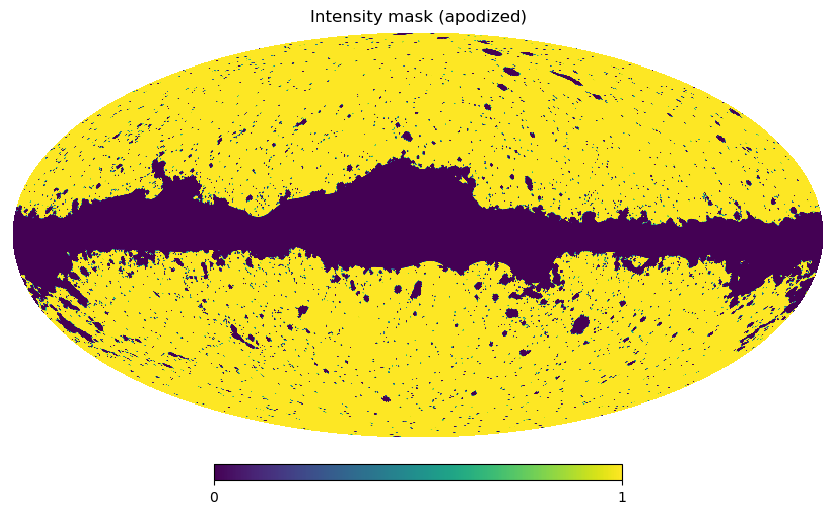

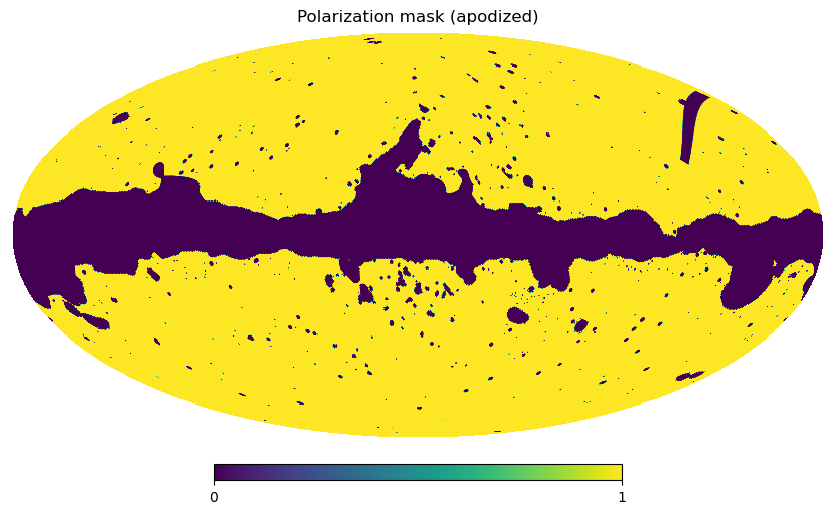

In [5]:
apodized_mask_t = patch.apodize_mask(common_mask_t, apodize_deg=0.3, method="C1")
apodized_mask_pol = patch.apodize_mask(common_mask_pol, apodize_deg=0.3, method="C1")

p_t_hm1 = patch.extract_patch(map_hm1_t, apodized_mask_t)
p_t_hm2 = patch.extract_patch(map_hm2_t, apodized_mask_t)
p_pol_hm1 = patch.extract_patch(np.array([map_hm1_q, map_hm1_u]), apodized_mask_pol)
p_pol_hm2 = patch.extract_patch(np.array([map_hm2_q, map_hm2_u]), apodized_mask_pol)
print(f"f_sky (T)   = {p_t_hm1['f_sky']:.4f}")
print(f"f_sky (Pol) = {p_pol_hm1['f_sky']:.4f}")

hp.mollview(apodized_mask_t, title="Intensity mask (apodized)")
hp.mollview(apodized_mask_pol, title="Polarization mask (apodized)")

## 2. Power spectra + joint covariance (NaMaster)

TT, TE, and EE cross-spectra between the two half-mission fields
(`hm1` x `hm2`), each decoupled through its own spin-appropriate
mode-coupling workspace (TT: spin0 x spin0, TE: spin0 x spin2, EE: spin2 x
spin2) -- temperature fields built from the intensity mask, polarization
fields from the polarization mask. All fields get a beam (5' Gaussian, the
SMICA common resolution) and HEALPix pixel-window correction folded in.

Each spectrum uses its own `lmax` (see `LMAX_TT/TE/EE` above) and its own
`NmtBin`/`NmtWorkspace`, following the paper's per-spectrum multipole
cuts. The first bandpower (ell=[2,31]) is dropped for all three, since the
sky fraction there is unreliable for a mask this size (again following the
paper).

In [6]:
beam_fwhm_arcmin = 5.0  # SMICA common resolution
beam_function = hp.gauss_beam(np.radians(beam_fwhm_arcmin / 60), lmax=LMAX)
pixel_window_t, pixel_window_pol = hp.pixwin(NSIDE, pol=True, lmax=LMAX)

field_t_hm1 = power_spectrum.build_field(
    p_t_hm1, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)
field_t_hm2 = power_spectrum.build_field(
    p_t_hm2, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)
field_pol_hm1 = power_spectrum.build_field(
    p_pol_hm1, spin=2, beam_function=beam_function, pixel_window_function=pixel_window_pol, lmax=LMAX
)
field_pol_hm2 = power_spectrum.build_field(
    p_pol_hm2, spin=2, beam_function=beam_function, pixel_window_function=pixel_window_pol, lmax=LMAX
)

# NaMaster requires a workspace's fields and bins to share the same lmax,
# so TT/TE/EE can't each get their own truncated-lmax bins here -- all
# three fields above already share lmax=LMAX, so they share one bins
# object too, and each spectrum's own multipole cut (LMAX_TT/TE/EE) is
# instead applied by truncating the *output* bandpowers below.
bins = power_spectrum.make_bins(NSIDE, bandpower_width=30, lmax=LMAX)

spec_tt = power_spectrum.compute_power_spectrum(field_t_hm1, bins, field_b=field_t_hm2)
spec_te = power_spectrum.compute_power_spectrum(field_t_hm1, bins, field_b=field_pol_hm2)
spec_ee = power_spectrum.compute_power_spectrum(field_pol_hm1, bins, field_b=field_pol_hm2)
workspace_tt, workspace_te, workspace_ee = (
    spec_tt["workspace"], spec_te["workspace"], spec_ee["workspace"]
)

# Bandpowers per spectrum after dropping bin 0 (ell=[2,31]): a linear
# Delta_ell=30 binning starting at ell=2 gives (lmax_cut - 1) // 30 bins
# covering ell=[2, lmax_cut] -- minus 1 for the dropped first bin.
def n_bins_upto(lmax_cut, bandpower_width=30, ell_start=2):
    return (lmax_cut - ell_start + 1) // bandpower_width - 1

n_tt = n_bins_upto(LMAX_TT)
n_te = n_bins_upto(LMAX_TE)
n_ee = n_bins_upto(LMAX_EE)

ell_tt, cl_tt_data = spec_tt["ell"][1:1 + n_tt], spec_tt["cl"][1:1 + n_tt]
ell_te, cl_te_data = spec_te["ell"][1:1 + n_te], spec_te["cl"][1:1 + n_te]
ell_ee, cl_ee_data = spec_ee["ell"][1:1 + n_ee], spec_ee["cl"][1:1 + n_ee]

cl_data = np.concatenate([cl_tt_data, cl_te_data, cl_ee_data])

# hm1 and hm2 have independent noise -- their cross-spectra above are
# noise-bias-free, but the *covariance* still needs each split's noise
# level, or it's badly underestimated at high ell where noise dominates the
# signal. Estimate it from the half-difference null map (hm1 - hm2)/2,
# which cancels the shared CMB signal and leaves pure noise. T and Pol
# noise are each estimated with their own mask, matching the mask each
# field is actually built from above.
noise_tt = power_spectrum.estimate_noise_cl(
    map_hm1_t, map_hm2_t, apodized_mask_t, LMAX,
    beam_function=beam_function, pixel_window_function=pixel_window_t, spin=0,
)
noise_ee = power_spectrum.estimate_noise_cl(
    [map_hm1_q, map_hm1_u], [map_hm2_q, map_hm2_u], apodized_mask_pol, LMAX,
    beam_function=beam_function, pixel_window_function=pixel_window_pol, spin=2,
)

covariance = power_spectrum.compute_joint_tt_te_ee_covariance(
    workspace_tt, workspace_te, workspace_ee,
    field_t_hm1, field_t_hm2, field_pol_hm1, field_pol_hm2,
    cl_fiducial["TT"], cl_fiducial["TE"], cl_fiducial["EE"], cl_fiducial["BB"],
    noise_tt, noise_ee,
    n_tt, n_te, n_ee,
)
errors = power_spectrum.compute_errors(covariance)
cov_inv = np.linalg.inv(covariance)

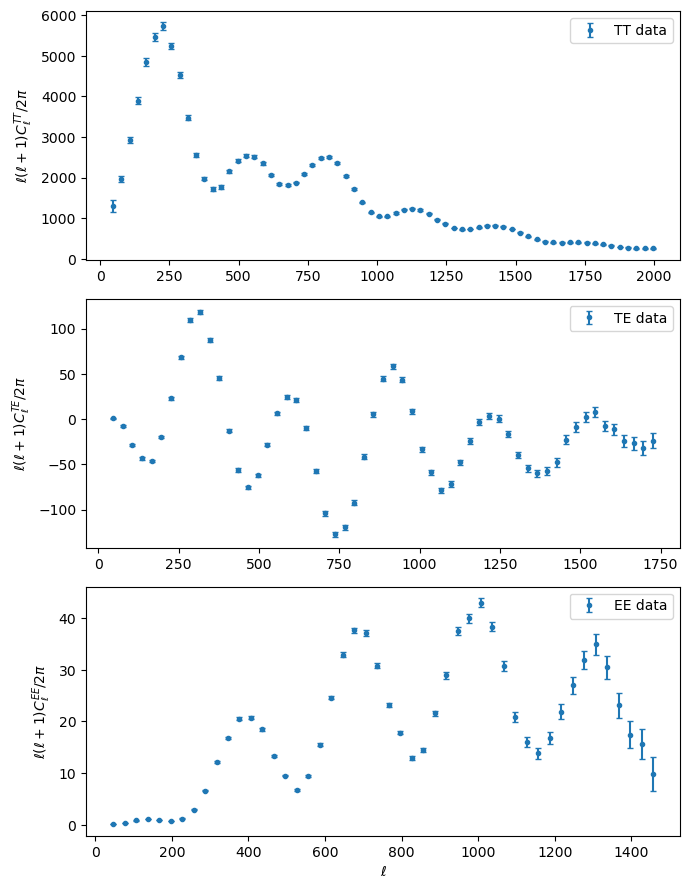

In [7]:
def to_dl(ell, cl):
    return ell * (ell + 1) / (2 * np.pi) * cl

ells = {"TT": ell_tt, "TE": ell_te, "EE": ell_ee}
data_by_spec = {"TT": cl_tt_data, "TE": cl_te_data, "EE": cl_ee_data}
error_slices = {
    "TT": slice(0, n_tt),
    "TE": slice(n_tt, n_tt + n_te),
    "EE": slice(n_tt + n_te, n_tt + n_te + n_ee),
}

fig, axes = plt.subplots(3, 1, figsize=(7, 9))
for ax, name in zip(axes, ["TT", "TE", "EE"]):
    ell = ells[name]
    dl = to_dl(ell, data_by_spec[name])
    dl_err = to_dl(ell, errors[error_slices[name]])
    ax.errorbar(ell, dl, yerr=dl_err, fmt="o", ms=3, capsize=2, label=f"{name} data")
    ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{%s}/2\pi$" % name)
    ax.legend()
axes[-1].set_xlabel(r"$\ell$")
plt.tight_layout()

## 3. Fit cosmological parameters (joint TT+TE+EE + nuisance)

`chi_square` pushes each trial CAMB spectrum through the *same* NaMaster
workspaces used to decouple the data, so theory and data live on the same
bandpowers before comparison -- skipping this step is the most common
source of a silently biased fit.

Following arXiv:2504.05597 sec. 2.2: tau, mnu, and r are fixed (see
`fitting.camb_cl` defaults) -- a single sky's polarization can't constrain
tau on its own -- and two point-source residual amplitudes (`A_ps_TT`,
`A_ps_EE`, modeled as `Dl ∝ ell^2` shot noise) are fit alongside the 5
LambdaCDM parameters.

Sanity check first: chi² at the fiducial (Planck 2018 best-fit) parameters
should be roughly the number of bandpowers, not wildly off.

In [9]:
fit_data = fitting.FitData(
    cl_data=cl_data,
    cov_inv=cov_inv,
    workspace_tt=workspace_tt,
    workspace_te=workspace_te,
    workspace_ee=workspace_ee,
    lmax=LMAX,
    n_tt=n_tt,
    n_te=n_te,
    n_ee=n_ee,
)

chi2_at_truth = fitting.chi_square(fit_data, **FIDUCIAL, A_ps_TT=50.0, A_ps_EE=0.0)
n_bins = len(cl_data)
print(f"chi^2 at fiducial params = {chi2_at_truth:.1f}  (n_bins = {n_bins})")

chi^2 at fiducial params = 286.1  (n_bins = 171)


In [10]:
initial_guess = dict(
    H0=70.0, ombh2=0.022, omch2=0.11, As=2.0e-9, ns=0.96,
    A_ps_TT=50.0, A_ps_EE=0.0,
)
bounds = dict(
    H0=(50, 90),
    ombh2=(0.01, 0.03),
    omch2=(0.05, 0.30),
    As=(1e-9, 4e-9),
    ns=(0.9, 1.05),
    A_ps_TT=(0, 200),
    A_ps_EE=(0, 20),
)
fixed_params_fullsky = set()  # this fit doesn't fix any parameters

fullsky_result = fitting.fit_parameters(fit_data, initial_guess, bounds, fixed=fixed_params_fullsky)

print("Converged:", fullsky_result["valid"])
print("chi^2 at best fit:", fullsky_result["chi2"])
for name, val in fullsky_result["best_fit"].items():
    err = fullsky_result["errors"][name]
    truth = FIDUCIAL.get(name)
    truth_str = f"  (Planck 2018 fiducial: {truth})" if truth is not None else ""
    print(f"  {name} = {val:.5g} +/- {err:.3g}{truth_str}")

# Save the full-sky best-fit parameters + errors. "fullsky" vs "patched"
# (Section 4) in the filename keeps the two scopes apart in output/ -- the
# fixed/all_varied tag just checks whether fixed_params_fullsky is empty.
FULLSKY_OUTPUT_DIR = "output"
os.makedirs(FULLSKY_OUTPUT_DIR, exist_ok=True)
_fixed_tag_fullsky = f"fixed({','.join(sorted(fixed_params_fullsky))})" if fixed_params_fullsky else "all_varied"
FULLSKY_TAG = _fixed_tag_fullsky

fullsky_params_path = os.path.join(FULLSKY_OUTPUT_DIR, f"fullsky_params_{FULLSKY_TAG}.txt")
with open(fullsky_params_path, "w") as f:
    f.write(f"# Full-sky best-fit parameters (TT+TE+EE, {_fixed_tag_fullsky})\n")
    f.write(f"converged={fullsky_result['valid']}  chi2={fullsky_result['chi2']:.2f}  n_bins={n_bins}\n")
    for name, val in fullsky_result["best_fit"].items():
        err = fullsky_result["errors"][name]
        truth = FIDUCIAL.get(name)
        truth_str = f"  (Planck 2018 fiducial: {truth})" if truth is not None else ""
        tag = " (fixed)" if name in fixed_params_fullsky else ""
        f.write(f"  {name} = {val:.6g} +/- {err:.4g}{truth_str}{tag}\n")
print(f"Saved {fullsky_params_path}")

Converged: True
chi^2 at best fit: 178.19879629529643
  H0 = 66.452 +/- 0.629  (Planck 2018 fiducial: 67.36)
  ombh2 = 0.022336 +/- 0.000167  (Planck 2018 fiducial: 0.02237)
  omch2 = 0.12186 +/- 0.00142  (Planck 2018 fiducial: 0.12)
  As = 2.1346e-09 +/- 9.4e-12  (Planck 2018 fiducial: 2.1e-09)
  ns = 0.96328 +/- 0.00496  (Planck 2018 fiducial: 0.9649)
  A_ps_TT = 47.486 +/- 8.52
  A_ps_EE = 5.1642 +/- 1.36
Saved output/fullsky_params_all_varied.txt


## 4. Twelve Nside=1 patches: independent TT+TE+EE fits per patch

Following the paper's per-patch analysis strategy (arXiv:2504.05597), split the sky into
the 12 disjoint superpixels of an Nside=1 HEALPix grid (`patch.make_superpixel_mask`),
each covering 1/12 of the sphere. Within each superpixel, intersect with the survey mask
used above (Int for temperature, Pol for polarization) and re-apodize -- so every patch
mask is still the survey's Galactic + point-source cut, just restricted to one region of
sky. Each patch then goes through the *same* cross-spectrum + joint-covariance + chi^2
pipeline as the full-sky fit above, fully independently (its own fields, mode-coupling
workspaces, covariance, and best-fit parameters) -- this is the sky-directional
consistency check the full-sky fit above can't do on its own (e.g. is $H_0$ isotropic
across the sky).

This section is self-contained: it only needs Section 1 (data loading) to have run, not
Sections 2/3's expensive full-sky spectrum/covariance/fit -- `beam_fwhm_arcmin`,
`to_dl`, `initial_guess`, and `bounds` are (re)defined locally below rather than reused
from Section 2/3, and the final comparison plot only draws the full-sky reference line if
Section 3's `result` happens to exist. Run Section 1, then jump straight here if you don't
want to pay for the full-sky fit.

Three patch-specific choices keep this tractable:
- **Downgrade to `NSIDE_PATCH=512`**: NaMaster's covariance workspace computation does
  spherical-harmonic transforms of the actual pixel *maps*, not just the truncated alm's
  -- so building this at the full `nside=2048` map resolution, once per patch, up to 6
  times per patch (TT/TE/EE cross-combinations, since T and Pol masks differ) x 12
  patches, is enough to exhaust available RAM and OOM-kill the kernel (confirmed via
  `dmesg`). `LMAX_PATCH` below never needed nside=2048 anyway -- 512 still safely
  oversamples ell<=1000 (Nyquist limit `3*512-1=1535`) at a fraction of the memory/CPU
  cost. Maps and masks are downgraded with `healpy.ud_grade` before patch masks are cut
  out of them.
- **Lower `LMAX_PATCH`** (1000 vs. the full-sky 2011): NaMaster's mode-coupling matrix
  still costs `O(lmax^3)` in time even at the lower resolution above.
- **Wider bandpowers** (`BANDPOWER_WIDTH_PATCH` vs. the full-sky `bandpower_width=30`):
  a patch covering ~1/12 of the sky has a much larger mode-coupling scale
  (roughly `pi / patch_size_rad`) than the full common-mask footprint, so the same narrow
  binning would leave bandpowers strongly correlated -- or the joint covariance
  numerically singular.

Patches the Galactic plane cut leaves with almost no usable sky (`f_sky` below
`MIN_FSKY`, in either mask) are skipped rather than fit -- there's not enough signal left
in them for a meaningful constraint. `gc.collect()` is called after every patch so each
patch's NaMaster C-allocated workspaces are freed before the next one is built, rather
than accumulating across the loop.

Text(0.5, 0.98, 'Nside=1 superpixel patches x intensity survey mask (apodized, Nside=2048)')

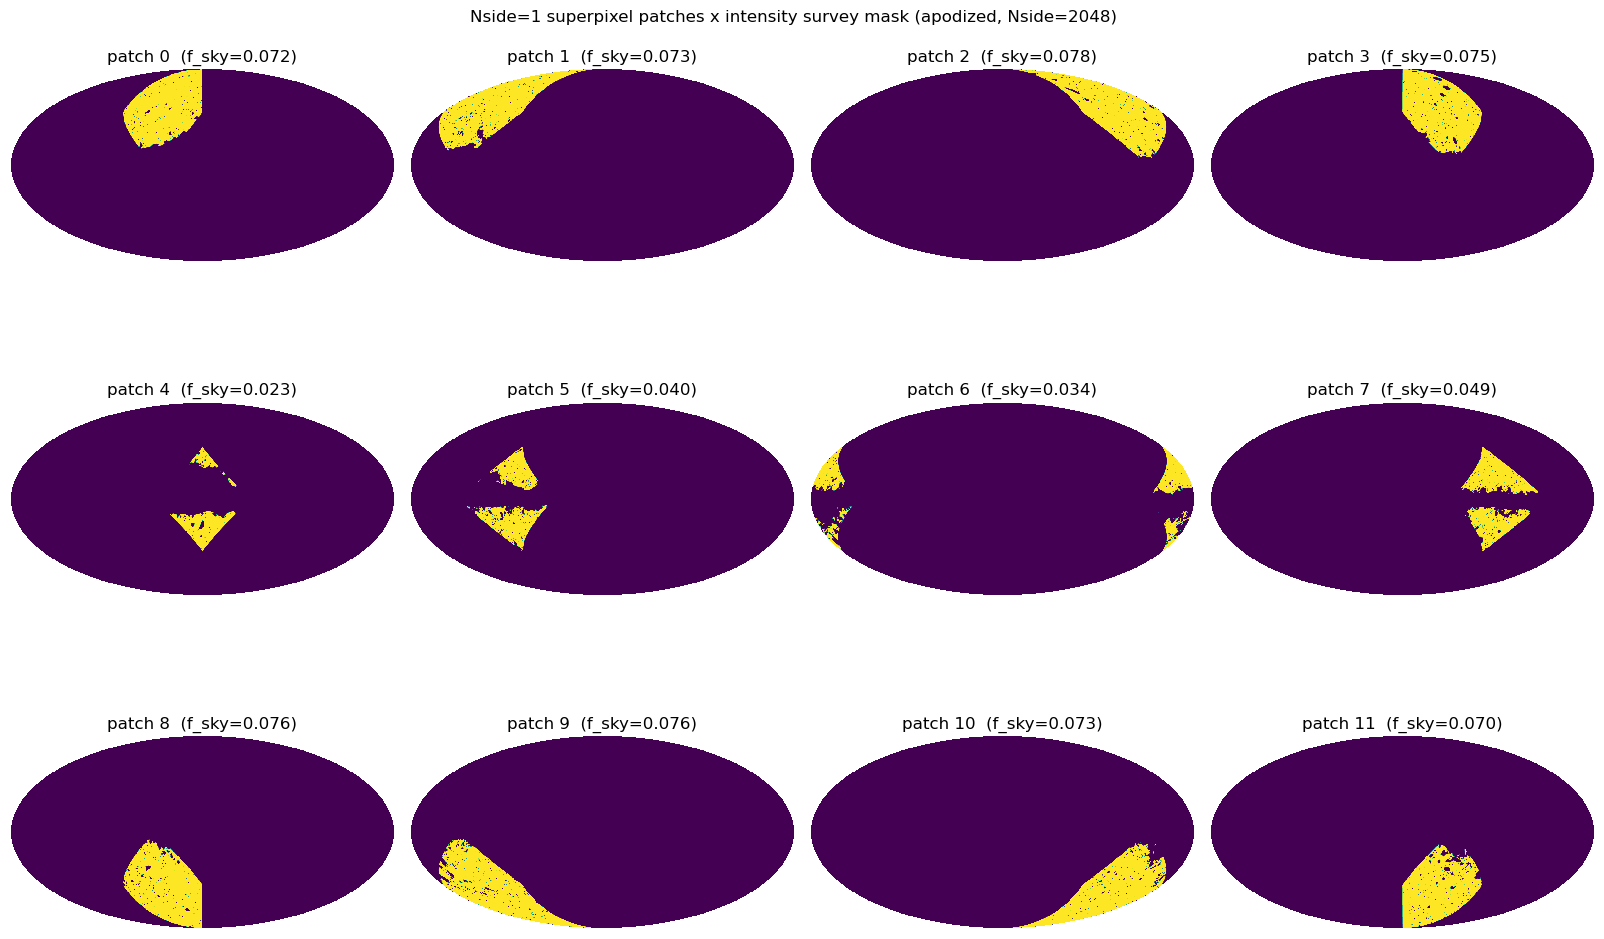

In [11]:
NSIDE_PATCH = 2048  # see markdown above -- LMAX_PATCH doesn't need nside=2048
NSIDE_LOW = 1
N_PATCHES = hp.nside2npix(NSIDE_LOW)  # 12

map_hm1_t_lo = hp.ud_grade(map_hm1_t, NSIDE_PATCH)
map_hm2_t_lo = hp.ud_grade(map_hm2_t, NSIDE_PATCH)
map_hm1_q_lo = hp.ud_grade(map_hm1_q, NSIDE_PATCH)
map_hm1_u_lo = hp.ud_grade(map_hm1_u, NSIDE_PATCH)
map_hm2_q_lo = hp.ud_grade(map_hm2_q, NSIDE_PATCH)
map_hm2_u_lo = hp.ud_grade(map_hm2_u, NSIDE_PATCH)
common_mask_t_lo = hp.ud_grade(common_mask_t, NSIDE_PATCH)
common_mask_pol_lo = hp.ud_grade(common_mask_pol, NSIDE_PATCH)

patch_masks_t, patch_masks_pol = [], []
patch_fsky_t, patch_fsky_pol = [], []
for i in range(N_PATCHES):
    super_mask = patch.make_superpixel_mask(NSIDE_PATCH, NSIDE_LOW, i)
    mask_t_i = patch.apodize_mask(super_mask * common_mask_t_lo, apodize_deg=0.3, method="C1")
    mask_pol_i = patch.apodize_mask(super_mask * common_mask_pol_lo, apodize_deg=0.3, method="C1")
    patch_masks_t.append(mask_t_i)
    patch_masks_pol.append(mask_pol_i)
    patch_fsky_t.append(np.mean(mask_t_i ** 2))
    patch_fsky_pol.append(np.mean(mask_pol_i ** 2))

plt.figure(figsize=(16, 10))
for i in range(N_PATCHES):
    hp.mollview(
        patch_masks_t[i], sub=(3, 4, i + 1), title=f"patch {i}  (f_sky={patch_fsky_t[i]:.3f})",
        cbar=False, notext=True, min=0, max=1,
    )
plt.suptitle(f"Nside=1 superpixel patches x intensity survey mask (apodized, Nside={NSIDE_PATCH})")

In [16]:
import gc

# Self-contained config for this section -- doesn't rely on Sections 2/3
# having run, so Section 4 works right after Section 1 (data loading)
# alone, without paying for the expensive full-sky spectrum/covariance/fit.
def to_dl(ell, cl):
    return ell * (ell + 1) / (2 * np.pi) * cl

beam_fwhm_arcmin = 5.0  # SMICA common resolution
initial_guess = dict(
    H0=70.0, ombh2=0.022, omch2=0.11, As=2.0e-9, ns=0.96,
    A_ps_TT=50.0, A_ps_EE=0.0,
)
FULLSKY_RESULT = dict(fullsky_result["best_fit"].items())
fixed_params = {"H0", "ombh2", "omch2",}  #"ns", "As", "H0", "ombh2", "omch2", "A_ps_TT", "A_ps_EE"
for _param in fixed_params:
    #FIDUCIAL[_param]
    initial_guess[_param] = FULLSKY_RESULT[_param]
bounds = dict(
    H0=(50, 90),
    ombh2=(0.01, 0.03),
    omch2=(0.05, 0.30),
    As=(1e-9, 4e-9),
    ns=(0.9, 1.05),
    A_ps_TT=(0, 200),
    A_ps_EE=(0, 20),
)

LMAX_PATCH = 1000
LMAX_TT_PATCH = LMAX_PATCH
LMAX_TE_PATCH = 850
LMAX_EE_PATCH = 700
BANDPOWER_WIDTH_PATCH = 90
MIN_FSKY = 0.02  # skip patches the Galactic-plane cut leaves too small to fit

# Output naming -- tags plots/parameter dumps below with which params were
# held fixed (e.g. "fixed(As,ns)", or "all_varied" if none). "patched" (vs
# Section 3/5's "fullsky") keeps the two scopes apart in output/.
PATCHED_OUTPUT_DIR = "output"
os.makedirs(PATCHED_OUTPUT_DIR, exist_ok=True)
_fixed_tag = f"fixed({','.join(sorted(fixed_params))})" if fixed_params else "all_varied"
PATCHED_TAG = _fixed_tag

beam_function_patch = hp.gauss_beam(np.radians(beam_fwhm_arcmin / 60), lmax=LMAX_PATCH)
pixel_window_t_patch, pixel_window_pol_patch = hp.pixwin(NSIDE_PATCH, pol=True, lmax=LMAX_PATCH)
cl_fiducial_patch = fitting.camb_cl(**FIDUCIAL, lmax=LMAX_PATCH)


def n_bins_upto(lmax_cut, bandpower_width=30, ell_start=2):
    return (lmax_cut - ell_start + 1) // bandpower_width - 1


def fit_one_patch(i):
    """Run the full TT+TE+EE cross-spectrum + covariance + chi^2 fit on patch i alone."""
    mask_t_i = patch_masks_t[i]
    mask_pol_i = patch_masks_pol[i]

    p_t_hm1_i = patch.extract_patch(map_hm1_t_lo, mask_t_i)
    p_t_hm2_i = patch.extract_patch(map_hm2_t_lo, mask_t_i)
    p_pol_hm1_i = patch.extract_patch(np.array([map_hm1_q_lo, map_hm1_u_lo]), mask_pol_i)
    p_pol_hm2_i = patch.extract_patch(np.array([map_hm2_q_lo, map_hm2_u_lo]), mask_pol_i)

    field_t_hm1_i = power_spectrum.build_field(
        p_t_hm1_i, spin=0, beam_function=beam_function_patch,
        pixel_window_function=pixel_window_t_patch, lmax=LMAX_PATCH,
    )
    field_t_hm2_i = power_spectrum.build_field(
        p_t_hm2_i, spin=0, beam_function=beam_function_patch,
        pixel_window_function=pixel_window_t_patch, lmax=LMAX_PATCH,
    )
    field_pol_hm1_i = power_spectrum.build_field(
        p_pol_hm1_i, spin=2, beam_function=beam_function_patch,
        pixel_window_function=pixel_window_pol_patch, lmax=LMAX_PATCH,
    )
    field_pol_hm2_i = power_spectrum.build_field(
        p_pol_hm2_i, spin=2, beam_function=beam_function_patch,
        pixel_window_function=pixel_window_pol_patch, lmax=LMAX_PATCH,
    )

    bins_i = power_spectrum.make_bins(NSIDE_PATCH, bandpower_width=BANDPOWER_WIDTH_PATCH, lmax=LMAX_PATCH)

    spec_tt_i = power_spectrum.compute_power_spectrum(field_t_hm1_i, bins_i, field_b=field_t_hm2_i)
    spec_te_i = power_spectrum.compute_power_spectrum(field_t_hm1_i, bins_i, field_b=field_pol_hm2_i)
    spec_ee_i = power_spectrum.compute_power_spectrum(field_pol_hm1_i, bins_i, field_b=field_pol_hm2_i)
    ws_tt_i, ws_te_i, ws_ee_i = spec_tt_i["workspace"], spec_te_i["workspace"], spec_ee_i["workspace"]

    n_tt_i = n_bins_upto(LMAX_TT_PATCH, BANDPOWER_WIDTH_PATCH)
    n_te_i = n_bins_upto(LMAX_TE_PATCH, BANDPOWER_WIDTH_PATCH)
    n_ee_i = n_bins_upto(LMAX_EE_PATCH, BANDPOWER_WIDTH_PATCH)

    ell_i = {
        "TT": spec_tt_i["ell"][1:1 + n_tt_i],
        "TE": spec_te_i["ell"][1:1 + n_te_i],
        "EE": spec_ee_i["ell"][1:1 + n_ee_i],
    }
    cl_i = {
        "TT": spec_tt_i["cl"][1:1 + n_tt_i],
        "TE": spec_te_i["cl"][1:1 + n_te_i],
        "EE": spec_ee_i["cl"][1:1 + n_ee_i],
    }
    cl_data_i = np.concatenate([cl_i["TT"], cl_i["TE"], cl_i["EE"]])

    noise_tt_i = power_spectrum.estimate_noise_cl(
        map_hm1_t_lo, map_hm2_t_lo, mask_t_i, LMAX_PATCH,
        beam_function=beam_function_patch, pixel_window_function=pixel_window_t_patch, spin=0,
    )
    noise_ee_i = power_spectrum.estimate_noise_cl(
        [map_hm1_q_lo, map_hm1_u_lo], [map_hm2_q_lo, map_hm2_u_lo], mask_pol_i, LMAX_PATCH,
        beam_function=beam_function_patch, pixel_window_function=pixel_window_pol_patch, spin=2,
    )

    cov_i = power_spectrum.compute_joint_tt_te_ee_covariance(
        ws_tt_i, ws_te_i, ws_ee_i,
        field_t_hm1_i, field_t_hm2_i, field_pol_hm1_i, field_pol_hm2_i,
        cl_fiducial_patch["TT"], cl_fiducial_patch["TE"], cl_fiducial_patch["EE"], cl_fiducial_patch["BB"],
        noise_tt_i, noise_ee_i,
        n_tt_i, n_te_i, n_ee_i,
    )
    errors_i = power_spectrum.compute_errors(cov_i)
    cov_inv_i = np.linalg.inv(cov_i)

    fit_data_i = fitting.FitData(
        cl_data=cl_data_i, cov_inv=cov_inv_i,
        workspace_tt=ws_tt_i, workspace_te=ws_te_i, workspace_ee=ws_ee_i,
        lmax=LMAX_PATCH, n_tt=n_tt_i, n_te=n_te_i, n_ee=n_ee_i,
    )
    result_i = fitting.fit_parameters(fit_data_i, initial_guess, bounds, fixed=fixed_params)

    return dict(
        f_sky_t=p_t_hm1_i["f_sky"], f_sky_pol=p_pol_hm1_i["f_sky"],
        ell=ell_i, cl_data=cl_i, errors=errors_i,
        error_slices={
            "TT": slice(0, n_tt_i),
            "TE": slice(n_tt_i, n_tt_i + n_te_i),
            "EE": slice(n_tt_i + n_te_i, n_tt_i + n_te_i + n_ee_i),
        },
        result=result_i,
    )


patch_results = {}
for i in range(N_PATCHES):
    if min(patch_fsky_t[i], patch_fsky_pol[i]) < MIN_FSKY:
        print(f"patch {i}: f_sky (T)={patch_fsky_t[i]:.4f}, (Pol)={patch_fsky_pol[i]:.4f} -- too small, skipped")
        continue
    print(f"patch {i}: f_sky (T)={patch_fsky_t[i]:.4f}, (Pol)={patch_fsky_pol[i]:.4f} -- fitting...")
    patch_results[i] = fit_one_patch(i)
    r = patch_results[i]["result"]
    print(f"  converged={r['valid']}  chi2={r['chi2']:.1f}  "
          f"H0={r['best_fit']['H0']:.2f} +/- {r['errors']['H0']:.2f}")
    gc.collect()

patch 0: f_sky (T)=0.0723, (Pol)=0.0767 -- fitting...
  converged=True  chi2=14.5  H0=66.45 +/- 0.66
patch 1: f_sky (T)=0.0730, (Pol)=0.0733 -- fitting...
  converged=True  chi2=29.7  H0=66.45 +/- 0.66
patch 2: f_sky (T)=0.0780, (Pol)=0.0769 -- fitting...
  converged=True  chi2=15.8  H0=66.45 +/- 0.66
patch 3: f_sky (T)=0.0753, (Pol)=0.0764 -- fitting...
  converged=True  chi2=30.7  H0=66.45 +/- 0.66
patch 4: f_sky (T)=0.0233, (Pol)=0.0244 -- fitting...
  converged=True  chi2=20.8  H0=66.45 +/- 0.66
patch 5: f_sky (T)=0.0403, (Pol)=0.0448 -- fitting...
  converged=True  chi2=12.2  H0=66.45 +/- 0.66
patch 6: f_sky (T)=0.0340, (Pol)=0.0352 -- fitting...
  converged=True  chi2=28.0  H0=66.45 +/- 0.66
patch 7: f_sky (T)=0.0494, (Pol)=0.0521 -- fitting...
  converged=True  chi2=22.5  H0=66.45 +/- 0.66
patch 8: f_sky (T)=0.0760, (Pol)=0.0777 -- fitting...
  converged=True  chi2=20.0  H0=66.45 +/- 0.66
patch 9: f_sky (T)=0.0755, (Pol)=0.0749 -- fitting...
  converged=True  chi2=62.4  H0=66.45

Saved output/patched_bandpowers_fixed(H0,ombh2,omch2).png


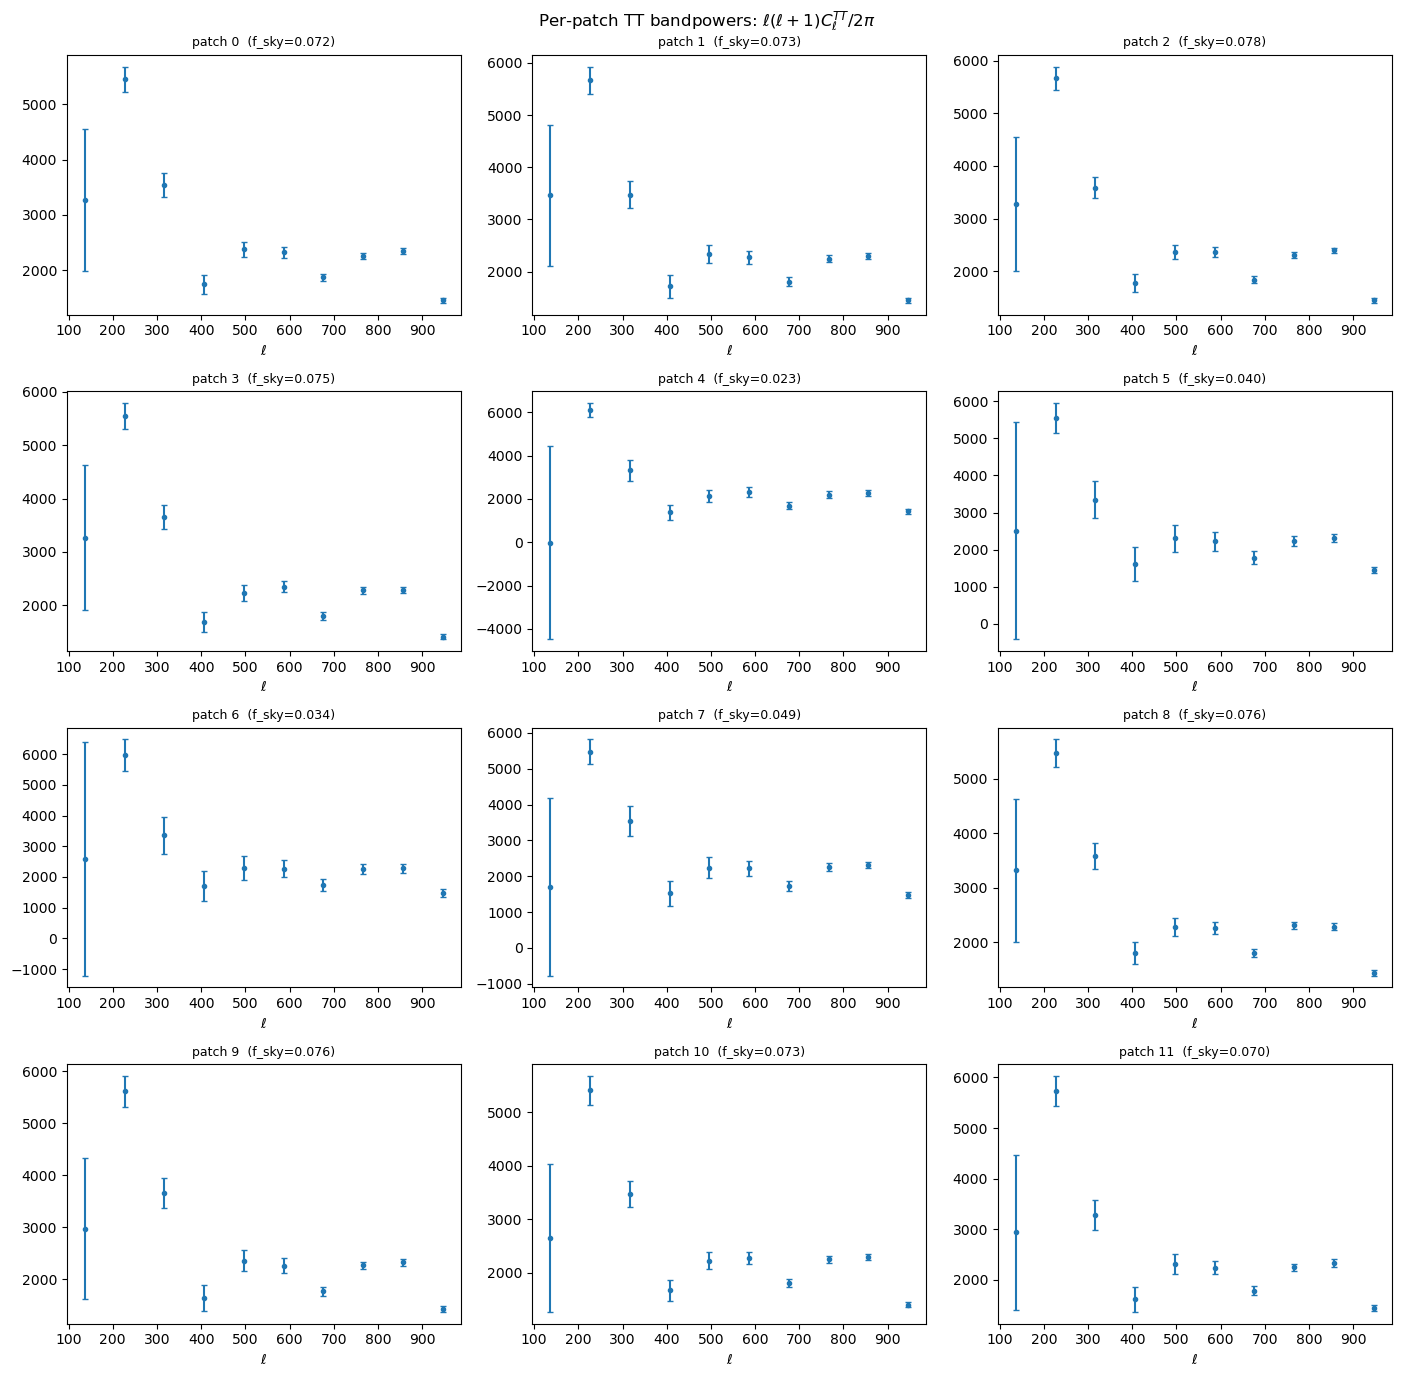

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
for i, ax in zip(range(N_PATCHES), axes.flat):
    if i not in patch_results:
        ax.set_visible(False)
        continue
    r = patch_results[i]
    ell = r["ell"]["TT"]
    dl = to_dl(ell, r["cl_data"]["TT"])
    dl_err = to_dl(ell, r["errors"][r["error_slices"]["TT"]])
    ax.errorbar(ell, dl, yerr=dl_err, fmt="o", ms=3, capsize=2)
    ax.set_title(f"patch {i}  (f_sky={r['f_sky_t']:.3f})", fontsize=9)
    ax.set_xlabel(r"$\ell$")
fig.suptitle(r"Per-patch TT bandpowers: $\ell(\ell+1)C_\ell^{TT}/2\pi$")
plt.tight_layout()

bandpowers_path = os.path.join(PATCHED_OUTPUT_DIR, f"patched_bandpowers_{PATCHED_TAG}.png")
fig.savefig(bandpowers_path, dpi=150)
print(f"Saved {bandpowers_path}")

Saved output/patched_params_fixed(H0,ombh2,omch2).png
Saved output/patched_params_fixed(H0,ombh2,omch2).txt


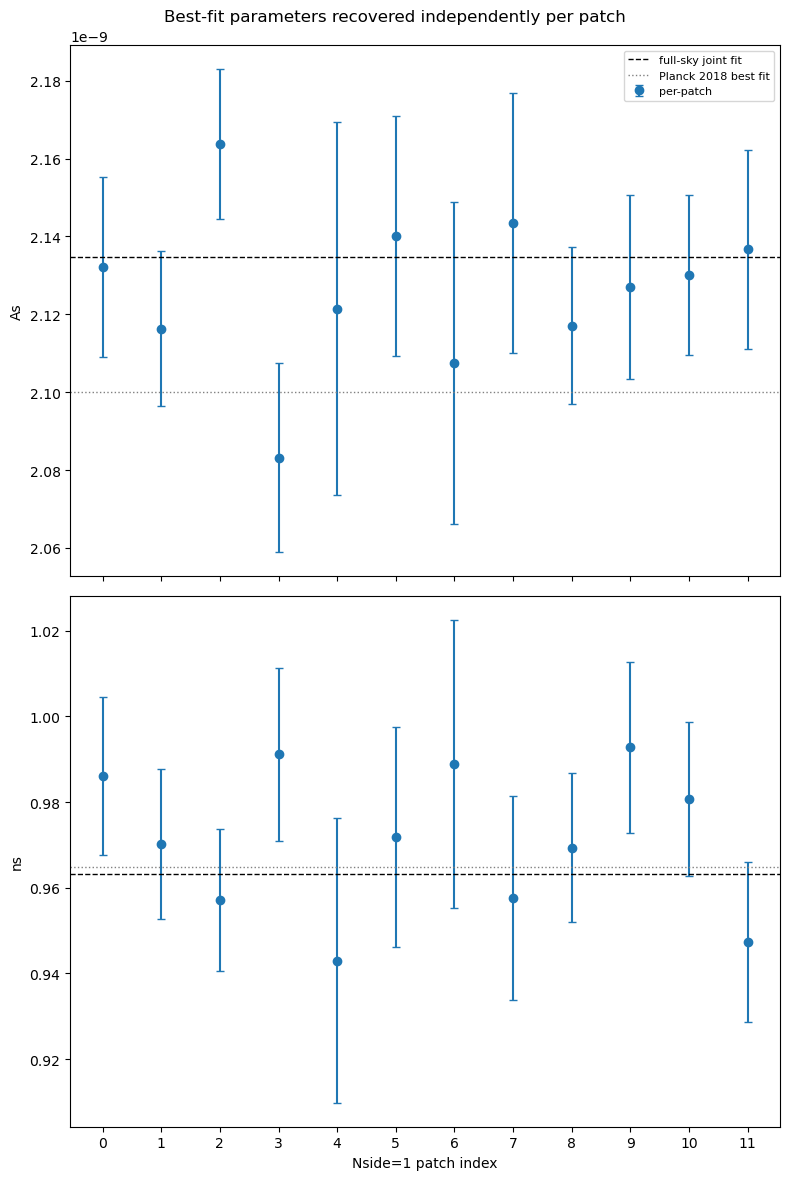

In [18]:
param_names = list(param for param in ["H0", "ombh2", "omch2", "As", "ns"] if not param in fixed_params)
patch_ids = sorted(patch_results)

fig, axes = plt.subplots(len(param_names), 1, figsize=(8, 12), sharex=True)
for ax, name in zip(axes, param_names):
    vals = [patch_results[i]["result"]["best_fit"][name] for i in patch_ids]
    errs = [patch_results[i]["result"]["errors"][name] for i in patch_ids]
    ax.errorbar(patch_ids, vals, yerr=errs, fmt="o", capsize=3, label="per-patch")
    if "fullsky_result" in globals():  # only if Section 3's full-sky fit was also run
        ax.axhline(fullsky_result["best_fit"][name], color="k", ls="--", lw=1, label="full-sky joint fit")
    ax.axhline(FIDUCIAL[name], color="gray", ls=":", lw=1, label="Planck 2018 best fit")
    ax.set_ylabel(name)
axes[0].legend(fontsize=8)
axes[-1].set_xlabel("Nside=1 patch index")
axes[-1].set_xticks(patch_ids)
fig.suptitle("Best-fit parameters recovered independently per patch")
plt.tight_layout()

params_plot_path = os.path.join(PATCHED_OUTPUT_DIR, f"patched_params_{PATCHED_TAG}.png")
fig.savefig(params_plot_path, dpi=150)
print(f"Saved {params_plot_path}")

# Dump each patch's best-fit parameters + errors (joint TT+TE+EE) to a text
# file alongside the plots, tagged the same way so the two stay paired.
params_txt_path = os.path.join(PATCHED_OUTPUT_DIR, f"patched_params_{PATCHED_TAG}.txt")
with open(params_txt_path, "w") as f:
    f.write(f"# Per-patch best-fit parameters (TT+TE+EE, {_fixed_tag})\n")
    for i in patch_ids:
        r = patch_results[i]["result"]
        f.write(f"\npatch {i}: f_sky (T)={patch_results[i]['f_sky_t']:.4f}, "
                f"(Pol)={patch_results[i]['f_sky_pol']:.4f}  "
                f"converged={r['valid']}  chi2={r['chi2']:.2f}\n")
        for name, val in r["best_fit"].items():
            err = r["errors"][name]
            tag = " (fixed)" if name in fixed_params else ""
            f.write(f"  {name} = {val:.6g} +/- {err:.4g}{tag}\n")
print(f"Saved {params_txt_path}")

## 5. Validate: residuals and best-fit overlay

In [ ]:
best_cosmo = {k: v for k, v in fullsky_result["best_fit"].items() if k in FIDUCIAL}
best_cl = fitting.camb_cl(**best_cosmo, lmax=LMAX)
zero = np.zeros(LMAX + 1)
ps_tt = fitting.point_source_dl_template(LMAX, fullsky_result["best_fit"]["A_ps_TT"])
ps_ee = fitting.point_source_dl_template(LMAX, fullsky_result["best_fit"]["A_ps_EE"])

theory_tt = fitting.decouple_theory(workspace_tt, [best_cl["TT"] + ps_tt])[1:1 + n_tt]
theory_te = fitting.decouple_theory(workspace_te, [best_cl["TE"], zero])[1:1 + n_te]
theory_ee = fitting.decouple_theory(workspace_ee, [best_cl["EE"] + ps_ee, zero, zero, best_cl["BB"]])[1:1 + n_ee]
ps_tt_binned = fitting.decouple_theory(workspace_tt, [ps_tt])[1:1 + n_tt]
ps_ee_binned = fitting.decouple_theory(workspace_ee, [ps_ee, zero, zero, zero])[1:1 + n_ee]

theory_by_spec = {"TT": theory_tt, "TE": theory_te, "EE": theory_ee}
ps_by_spec = {"TT": ps_tt_binned, "EE": ps_ee_binned}

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for row, name in enumerate(["TT", "TE", "EE"]):
    ell = ells[name]
    ax_spec, ax_res = axes[row]

    dl_data = to_dl(ell, data_by_spec[name])
    dl_err = to_dl(ell, errors[error_slices[name]])
    dl_theory = to_dl(ell, theory_by_spec[name])

    ax_spec.errorbar(ell, dl_data, yerr=dl_err, fmt="o", ms=3, capsize=2, label="data")
    ax_spec.plot(ell, dl_theory, "-", label="best-fit theory")
    if name in ps_by_spec:
        ax_spec.plot(ell, to_dl(ell, ps_by_spec[name]), "k--", lw=1,
                     label=f"$A_{{ps}}^{{{name}}}$")
    ax_spec.set_ylabel(r"$\ell(\ell+1)C_\ell^{%s}/2\pi$" % name)
    ax_spec.legend(fontsize=8)

    residual = (data_by_spec[name] - theory_by_spec[name]) / errors[error_slices[name]]
    ax_res.axhline(0, color="k", lw=0.8)
    ax_res.plot(ell, residual, "o", ms=3)
    ax_res.set_ylabel(r"$(\mathrm{data-theory})/\sigma$")

axes[-1][0].set_xlabel(r"$\ell$")
axes[-1][1].set_xlabel(r"$\ell$")
plt.tight_layout()

fullsky_spectrum_path = os.path.join(FULLSKY_OUTPUT_DIR, f"fullsky_spectrum_{FULLSKY_TAG}.png")
fig.savefig(fullsky_spectrum_path, dpi=150)
print(f"Saved {fullsky_spectrum_path}")

# 6. Fixed parameter example

In [ ]:
# To fix one or more parameters at their initial_guess value and fit only
# the rest, pass `fixed={...}` (a set of parameter names). Fixed params
# still need an entry in initial_guess (that's the value they're held at)
# but don't need bounds. Errors/minos are only computed for the free ones.
result_fixed = fitting.fit_parameters(
    fit_data, initial_guess, bounds, fixed={"ns", "A_ps_EE"}
)

print("Converged:", result_fixed["valid"])
print("chi^2 at best fit:", result_fixed["chi2"])
for name, val in result_fixed["best_fit"].items():
    err = result_fixed["errors"][name]
    tag = " (fixed)" if name in {"ns", "A_ps_EE"} else ""
    print(f"  {name} = {val:.5g} +/- {err:.3g}{tag}")

## 6.1 Parameter constraints

Simple 2-parameter contour scan (Ωm-related: `omch2` vs `H0`) using iminuit's
built-in profile likelihood contour. For a full corner plot across all
parameters, loop over pairs and call `mncontour` for each, or export
`result["minuit"].covariance` to a corner-plot library.

In [ ]:
m = fullsky_result["minuit"]
plt.figure(figsize=(5, 5))
m.draw_mncontour("H0", "omch2", cl=[1, 2])
plt.title(r"$1\sigma$/$2\sigma$ contours: $H_0$ vs $\Omega_c h^2$")
plt.tight_layout()